In [1]:
!pip install grad-cam -q
print("Done!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 43.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Done!


In [4]:
from google.colab import files
import zipfile, os

uploaded = files.upload()


Saving rice_dataset.zip.zip to rice_dataset.zip.zip


In [5]:
with zipfile.ZipFile("rice_dataset.zip", "r") as z:
    z.extractall("data/raw/")

print("Extracted! Let's check folders:")
for folder in os.listdir("data/raw/"):
    path = f"data/raw/{folder}"
    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"  {folder}: {count} images")

FileNotFoundError: [Errno 2] No such file or directory: 'rice_dataset.zip'

In [6]:
import os
os.listdir("/content")

['.config',
 'rice-leaf-disease-detection.zip',
 'rice_dataset.zip.zip',
 'sample_data']

In [7]:
with zipfile.ZipFile("rice_dataset.zip.zip", "r") as z:
    z.extractall("data/raw/")

print("Extracted! Let's check folders:")
for folder in os.listdir("data/raw/"):
    path = f"data/raw/{folder}"
    if os.path.isdir(path):
        count = len(os.listdir(path))
        print(f"  {folder}: {count} images")

Extracted! Let's check folders:
  Brown spot: 40 images
  Bacterial leaf blight: 40 images
  Leaf smut: 39 images


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


In [9]:
# Dataset path
DATA_DIR = "data/raw"
CLASSES = ["Bacterial leaf blight", "Brown spot", "Leaf smut"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Classes found:")
for cls in CLASSES:
    path = os.path.join(DATA_DIR, cls)
    count = len(os.listdir(path))
    print(f"  {cls}: {count} images")

Classes found:
  Bacterial leaf blight: 40 images
  Brown spot: 40 images
  Leaf smut: 39 images


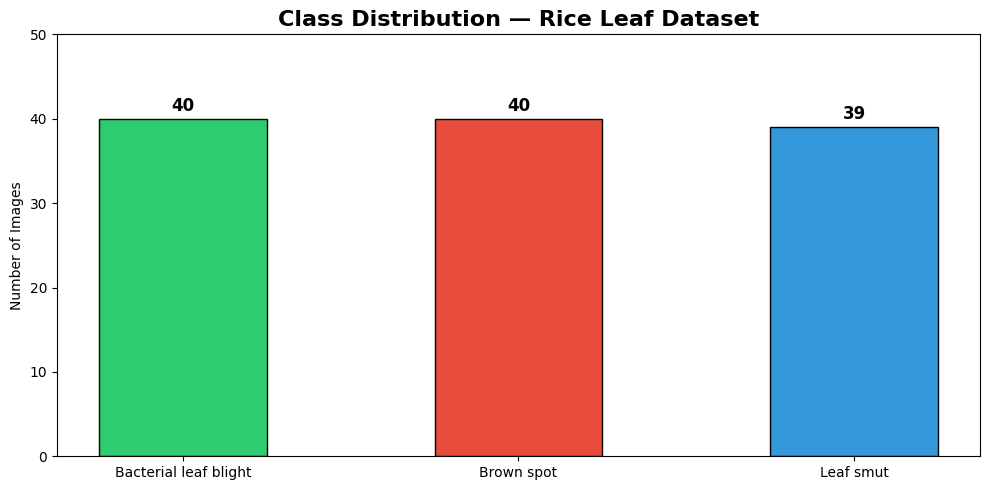

Dataset is balanced ✓


In [10]:
# Count images per class
class_counts = {}
for cls in CLASSES:
    path = os.path.join(DATA_DIR, cls)
    class_counts[cls] = len(os.listdir(path))

# Plot
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', width=0.5)

for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Class Distribution — Rice Leaf Dataset', fontsize=16, fontweight='bold')
plt.ylabel('Number of Images')
plt.ylim(0, 50)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Dataset is balanced ✓")

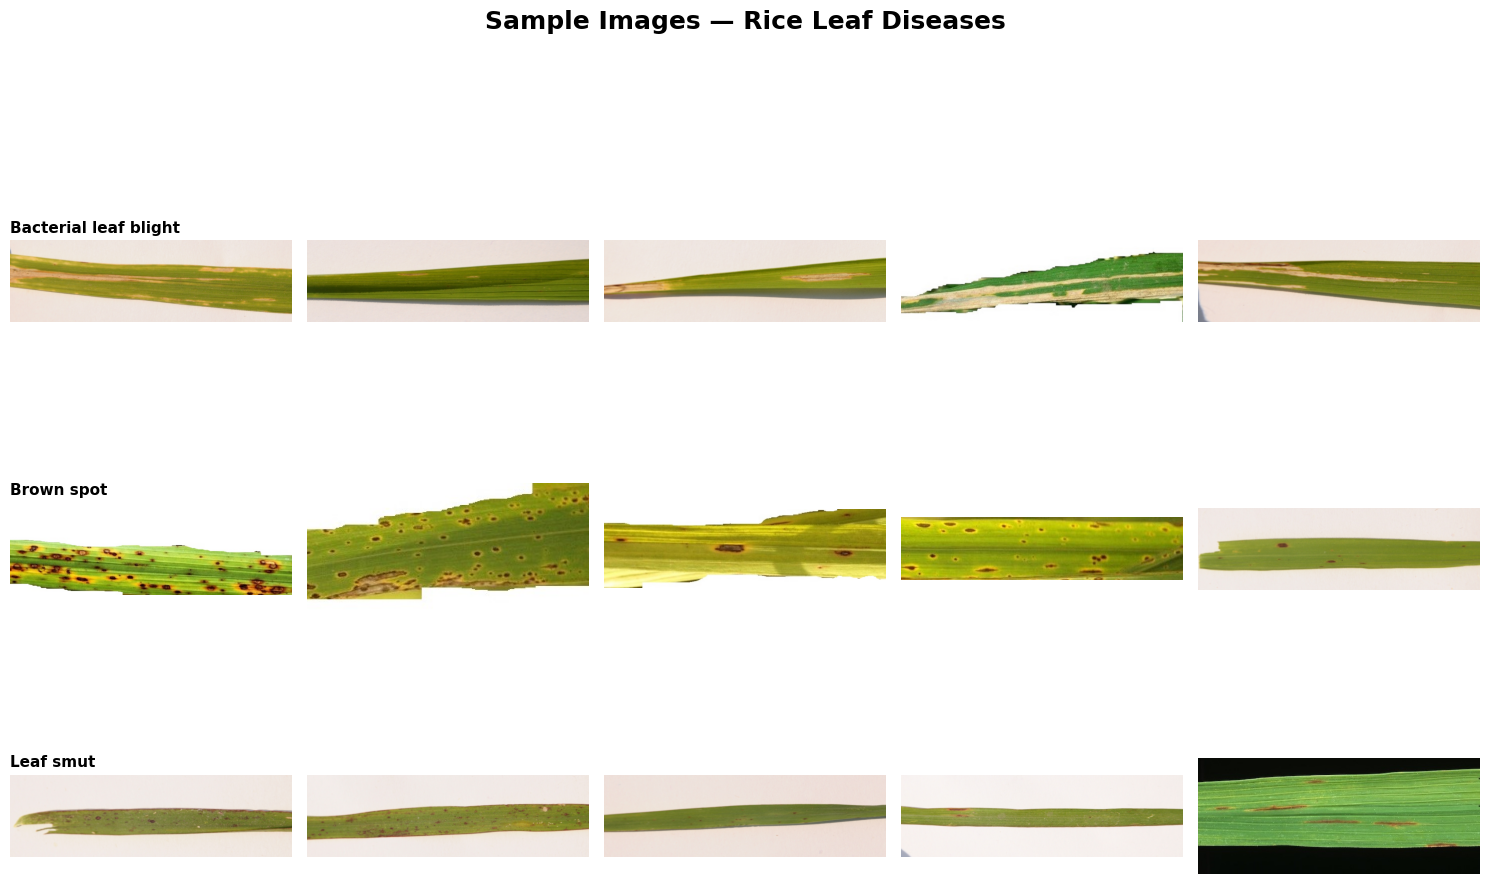

In [11]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
fig.suptitle('Sample Images — Rice Leaf Diseases', fontsize=18, fontweight='bold', y=1.02)

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(DATA_DIR, cls)
    images = os.listdir(cls_path)[:5]

    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

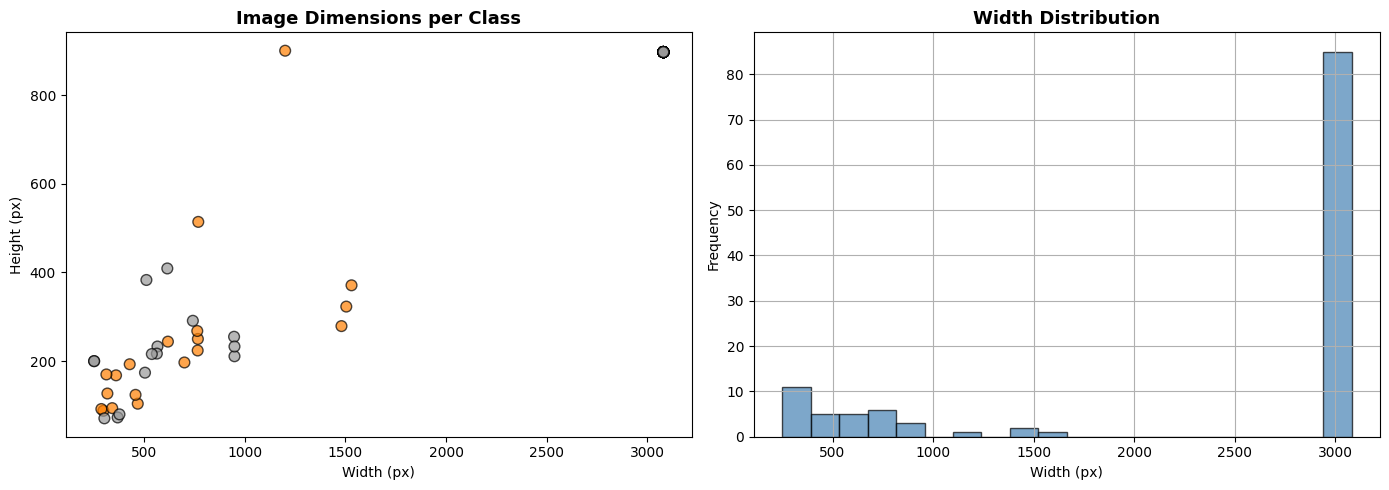

Average Width:  2384px
Average Height: 708px
Min size: 250 x 71
Max size: 3081 x 900


In [12]:
widths, heights, class_labels = [], [], []

for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            class_labels.append(cls)

df_dims = pd.DataFrame({'Width': widths, 'Height': heights, 'Class': class_labels})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_dims['Width'], df_dims['Height'],
                c=[CLASSES.index(c) for c in df_dims['Class']],
                cmap='Set1', alpha=0.7, edgecolors='black', s=60)
axes[0].set_title('Image Dimensions per Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')

df_dims['Width'].hist(ax=axes[1], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Width Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Width (px)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dimension_analysis.png', dpi=150)
plt.show()

print(f"Average Width:  {df_dims['Width'].mean():.0f}px")
print(f"Average Height: {df_dims['Height'].mean():.0f}px")
print(f"Min size: {df_dims['Width'].min()} x {df_dims['Height'].min()}")
print(f"Max size: {df_dims['Width'].max()} x {df_dims['Height'].max()}")

In [13]:
# No Augmentation
train_datagen_none = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Basic Augmentation
train_datagen_basic = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# Advanced Augmentation
train_datagen_advanced = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='reflect',
    validation_split=0.2
)

print("Augmentation pipelines ready ✓")

Augmentation pipelines ready ✓


In [14]:
def get_generators(datagen, data_dir):
    train_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        seed=SEED
    )
    val_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        seed=SEED
    )
    return train_gen, val_gen

train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Training samples:   {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.

Class indices: {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}
Training samples:   96
Validation samples: 23


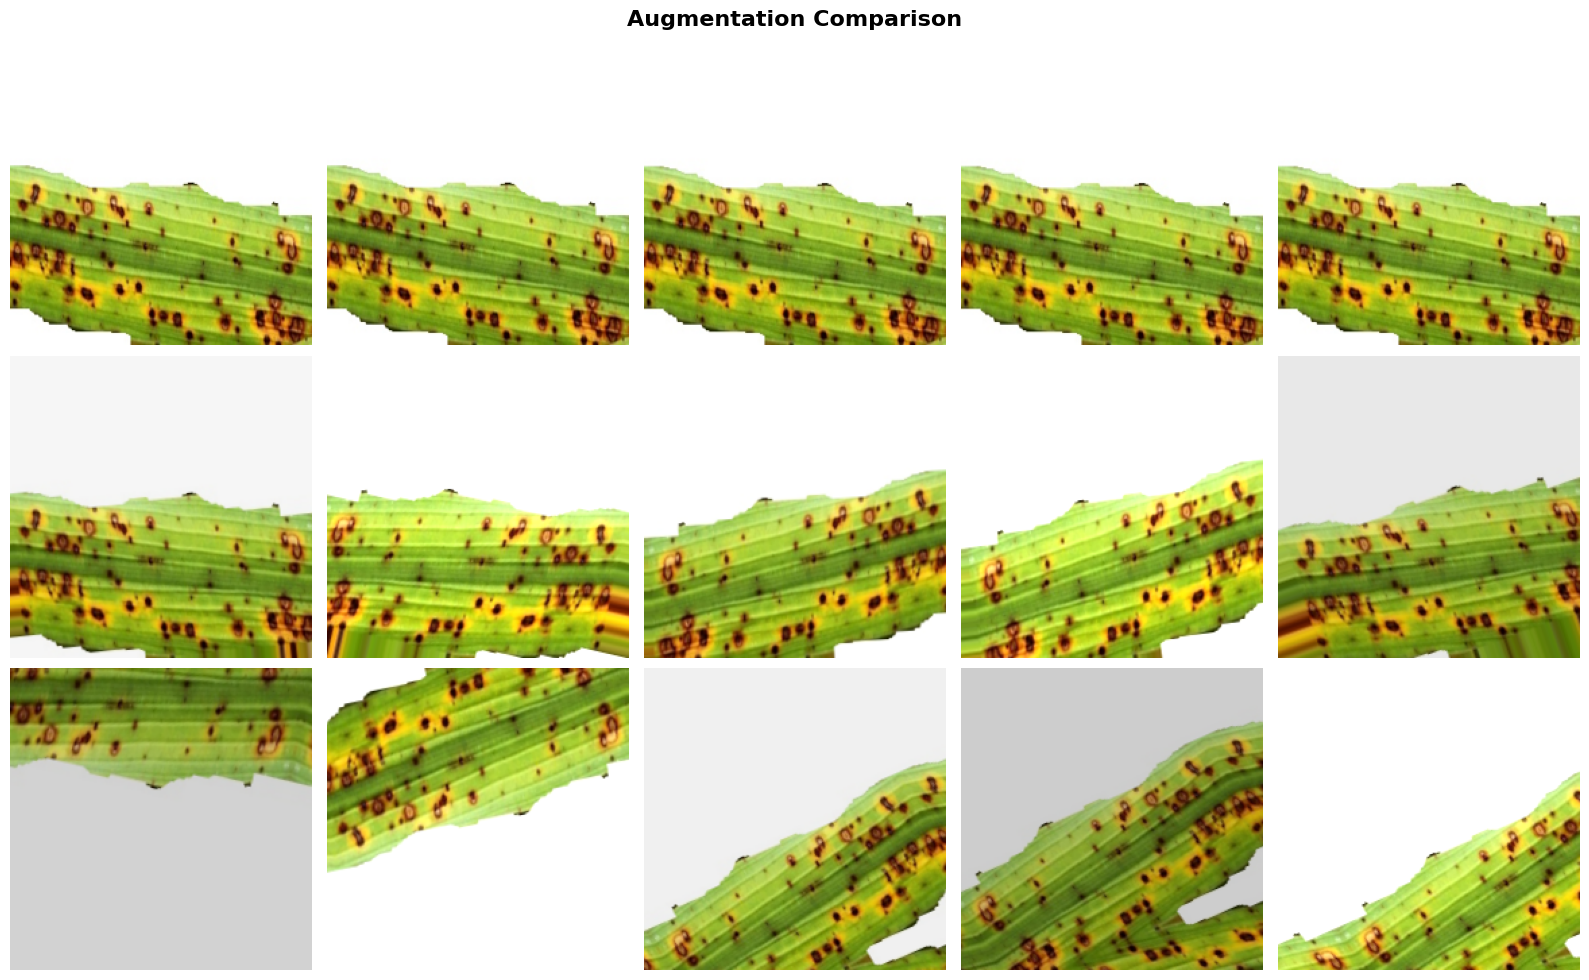

In [15]:
sample_cls = "Brown spot"
sample_img_path = os.path.join(DATA_DIR, sample_cls, os.listdir(os.path.join(DATA_DIR, sample_cls))[0])
sample_img = np.array(Image.open(sample_img_path).resize(IMG_SIZE))

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle('Augmentation Comparison', fontsize=16, fontweight='bold')

aug_configs = [
    ("No Augmentation", train_datagen_none),
    ("Basic Augmentation", train_datagen_basic),
    ("Advanced Augmentation", train_datagen_advanced)
]

for row, (title, datagen) in enumerate(aug_configs):
    img_array = sample_img.reshape((1,) + sample_img.shape)
    aug_gen = datagen.flow(img_array, batch_size=1)
    axes[row, 0].set_ylabel(title, fontsize=10, fontweight='bold')
    for col in range(5):
        aug_img = next(aug_gen)[0]
        axes[row, col].imshow(aug_img)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150)
plt.show()

In [16]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(3, activation='softmax')
    ], name="Custom_CNN")
    return model


def build_transfer_model(base_name):
    if base_name == "MobileNetV2":
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif base_name == "EfficientNetB0":
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif base_name == "ResNet50":
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(3, activation='softmax')
    ], name=base_name)
    return model

print("Model builder functions ready ✓")

Model builder functions ready ✓


In [17]:
def train_model(model, train_gen, val_gen, epochs=30, model_name="model"):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-7, verbose=1)
    ]

    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    # Final accuracy
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    print(f"\n✅ {model_name} — Val Accuracy: {val_acc*100:.2f}%")

    return history, val_acc

print("Training function ready ✓")

Training function ready ✓


In [18]:
# Reset generators
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

cnn_model = build_custom_cnn()
cnn_history, cnn_acc = train_model(cnn_model, train_gen, val_gen, epochs=30, model_name="Custom CNN")

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.

Training: Custom CNN
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3854 - loss: 1.2827 - val_accuracy: 0.3043 - val_loss: 1.1032 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5312 - loss: 1.0673 - val_accuracy: 0.6087 - val_loss: 1.0914 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5938 - loss: 0.8168 - val_accuracy: 0.3043 - val_loss: 1.0948 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5729 - loss: 0.8781 - val_accuracy: 0.3043 - val_loss: 1.1006 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7500 - loss: 0.6483 - val_accuracy: 0.3478 - val_loss: 1.1150 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7188 - loss: 0.6626
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
3/3 ━

In [19]:
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

mobilenet_model = build_transfer_model("MobileNetV2")
mobilenet_history, mobilenet_acc = train_model(
    mobilenet_model, train_gen, val_gen, epochs=30, model_name="MobileNetV2"
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training: MobileNetV2
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.4271 - loss: 1.2826 - val_accuracy: 0.6957 - val_loss: 0.7463 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6979 - loss: 0.6734 - val_accuracy: 0.7391 - val_loss: 0.5914 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7604 - loss: 0.4942 - val_accuracy: 0.8696 - val_loss: 0.3437 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8542 - loss: 0.3956 - val_accuracy: 0.9130 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8333 - loss: 0.4454 - val_accuracy: 0.8261 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 982ms/step - accuracy: 0.9375 - loss: 0.2304 - val_accuracy: 0.9130 - val

In [20]:
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

efficientnet_model = build_transfer_model("EfficientNetB0")
efficientnet_history, efficientnet_acc = train_model(
    efficientnet_model, train_gen, val_gen, epochs=30, model_name="EfficientNetB0"
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training: EfficientNetB0
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.3854 - loss: 1.1647 - val_accuracy: 0.3043 - val_loss: 1.1587 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.2604 - loss: 1.1660 - val_accuracy: 0.3478 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3958 - loss: 1.1425 - val_accuracy: 0.3478 - val_loss: 1.1156 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3021 - loss: 1.1897 - val_accuracy: 0.3043 - val_loss: 1.1278 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 979ms/step - accuracy: 0.3438 - loss: 1.1324 - val_accuracy: 0.3478 - val_loss: 1.1209 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3333 - loss: 1.1217 - val_accuracy: 0.3478 

In [21]:
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

resnet_model = build_transfer_model("ResNet50")
resnet_history, resnet_acc = train_model(
    resnet_model, train_gen, val_gen, epochs=30, model_name="ResNet50"
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Training: ResNet50
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.2812 - loss: 1.4574 - val_accuracy: 0.3478 - val_loss: 1.4104 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3854 - loss: 1.4138 - val_accuracy: 0.3478 - val_loss: 1.1153 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3229 - loss: 1.2362 - val_accuracy: 0.3478 - val_loss: 1.1969 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3646 - loss: 1.1745 - val_accuracy: 0.2609 - val_loss: 1.1209 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3958 - loss: 1.1667 - val_accuracy: 0.3478 - val_loss: 1.1359 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.2604 - loss: 1.2370
Epoch 6: ReduceLROnPlateau re

In [22]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Load all images as flat arrays
X, y = [], []

for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path).resize((64, 64)).convert('RGB')
        X.append(np.array(img).flatten())
        y.append(cls)

X = np.array(X) / 255.0
y = np.array(y)

# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# SVM
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
print(f"✅ SVM Accuracy: {svm_acc*100:.2f}%")

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")

✅ SVM Accuracy: 62.50%
✅ Random Forest Accuracy: 75.00%


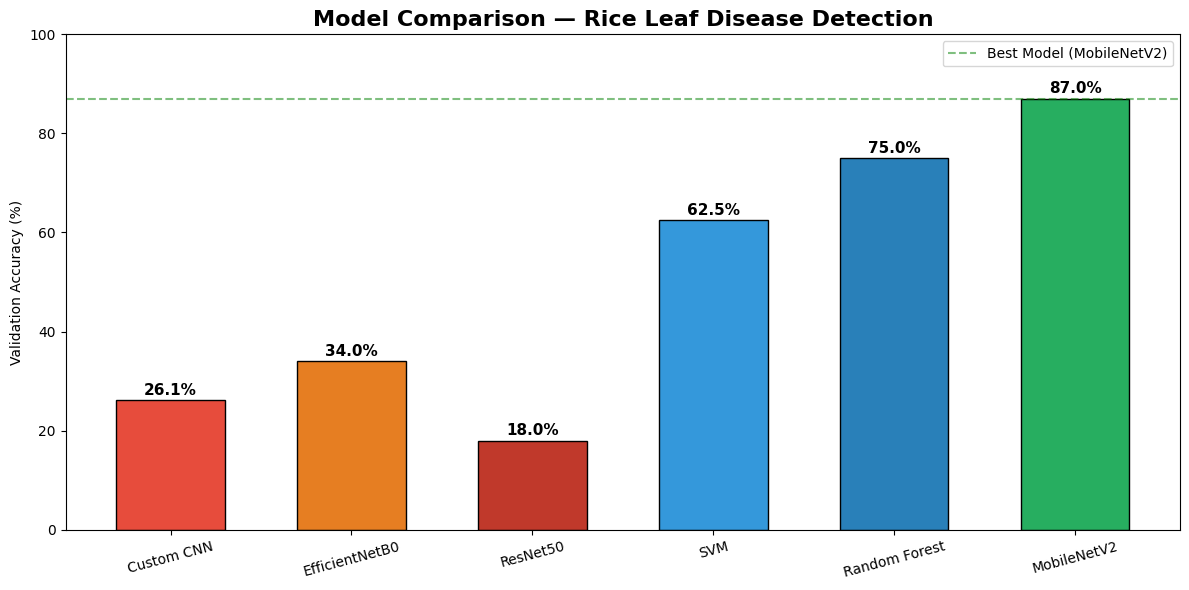

In [23]:
 models_names = ['Custom CNN', 'EfficientNetB0', 'ResNet50', 'SVM', 'Random Forest', 'MobileNetV2']
accuracies = [26.09, 34.00, 18.00, 62.50, 75.00, 86.96]
colors = ['#e74c3c', '#e67e22', '#c0392b', '#3498db', '#2980b9', '#27ae60']

plt.figure(figsize=(12, 6))
bars = plt.bar(models_names, accuracies, color=colors, edgecolor='black', width=0.6)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Model Comparison — Rice Leaf Disease Detection', fontsize=16, fontweight='bold')
plt.ylabel('Validation Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.axhline(y=86.96, color='green', linestyle='--', alpha=0.5, label='Best Model (MobileNetV2)')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


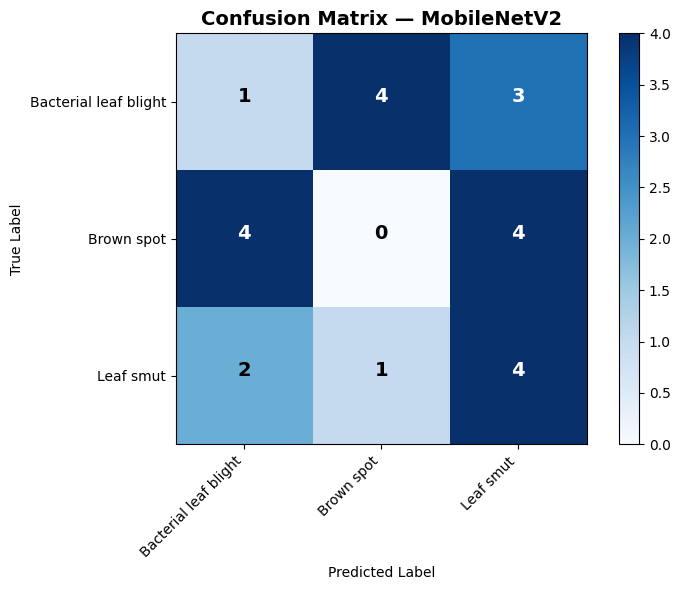


Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.14      0.12      0.13         8
           Brown spot       0.00      0.00      0.00         8
            Leaf smut       0.36      0.57      0.44         7

             accuracy                           0.22        23
            macro avg       0.17      0.23      0.19        23
         weighted avg       0.16      0.22      0.18        23



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Get predictions
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)
y_pred_probs = mobilenet_model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

class_names = list(val_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — MobileNetV2', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]), horizontalalignment='center',
             color='white' if cm[i, j] > cm.max()/2 else 'black',
             fontsize=14, fontweight='bold')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [1]:
import itertools

# Create fresh val generator with shuffle=False for evaluation
val_gen_eval = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False  # Important!
)

# Get predictions
y_pred_probs = mobilenet_model.predict(val_gen_eval, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen_eval.classes
class_names = list(val_gen_eval.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — MobileNetV2', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]), horizontalalignment='center',
             color='white' if cm[i, j] > cm.max()/2 else 'black',
             fontsize=14, fontweight='bold')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tigh

NameError: name 'ImageDataGenerator' is not defined

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
import itertools
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
GPU: True


In [3]:
DATA_DIR = "data/raw"
CLASSES = ["Bacterial leaf blight", "Brown spot", "Leaf smut"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen_advanced = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='reflect',
    validation_split=0.2
)

def get_generators(datagen, data_dir):
    train_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        seed=SEED
    )
    val_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        seed=SEED
    )
    return train_gen, val_gen

def build_transfer_model(base_name):
    if base_name == "MobileNetV2":
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif base_name == "EfficientNetB0":
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
    elif base_name == "ResNet50":
        base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(3, activation='softmax')
    ], name=base_name)
    return model

def train_model(model, train_gen, val_gen, epochs=30, model_name="model"):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-7, verbose=1)
    ]
    print(f"\nTraining: {model_name}")
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    print(f"\n✅ {model_name} — Val Accuracy: {val_acc*100:.2f}%")
    return history, val_acc

print("Everything restored ✓")

Everything restored ✓


In [4]:
train_gen, val_gen = get_generators(train_datagen_advanced, DATA_DIR)

mobilenet_model = build_transfer_model("MobileNetV2")
mobilenet_history, mobilenet_acc = train_model(
    mobilenet_model, train_gen, val_gen, epochs=30, model_name="MobileNetV2"
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw'

In [5]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

Saving rice_dataset.zip.zip to rice_dataset.zip.zip


In [6]:
with zipfile.ZipFile("rice_dataset.zip.zip", "r") as z:
    z.extractall("data/raw/")

print("Done! Folders:")
for folder in os.listdir("data/raw/"):
    path = f"data/raw/{folder}"
    if os.path.isdir(path):
        print(f"  {folder}: {len(os.listdir(path))} images")

Done! Folders:
  Brown spot: 40 images
  Bacterial leaf blight: 40 images
  Leaf smut: 39 images


In [7]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [8]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ValueError: mount failed

In [11]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


MessageError: Error: credential propagation was unsuccessful

In [12]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [13]:
import os
os.makedirs('/content/drive/MyDrive/RiceLeafProject', exist_ok=True)
print("Google Drive folder created ✓")

Google Drive folder created ✓


In [14]:
import shutil

shutil.copytree(
    'data/raw',
    '/content/drive/MyDrive/RiceLeafProject/data',
    dirs_exist_ok=True
)
print("Dataset saved to Google Drive ✓")

Dataset saved to Google Drive ✓


In [15]:
# Change DATA_DIR to point to Drive
DATA_DIR = '/content/drive/MyDrive/RiceLeafProject/data'

print("Folders:")
for folder in os.listdir(DATA_DIR):
    path = f"{DATA_DIR}/{folder}"
    if os.path.isdir(path):
        print(f"  {folder}: {len(os.listdir(path))} images")

Folders:
  Brown spot: 40 images
  Bacterial leaf blight: 40 images
  Leaf smut: 39 images


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
import itertools
warnings.filterwarnings('ignore')

from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.20.0
GPU: True


In [17]:
DATA_DIR = '/content/drive/MyDrive/RiceLeafProject/data'
CLASSES = ["Bacterial leaf blight", "Brown spot", "Leaf smut"]
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='reflect',
    validation_split=0.2
)

def get_generators(datagen, data_dir):
    train_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training',
        seed=SEED
    )
    val_gen = datagen.flow_from_directory(
        data_dir,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation',
        seed=SEED
    )
    return train_gen, val_gen

print("Setup done ✓")

Setup done ✓


In [18]:
train_gen, val_gen = get_generators(train_datagen, DATA_DIR)

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

mobilenet_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')
], name="MobileNetV2")

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=4, min_lr=1e-7, verbose=1)
]

history = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = mobilenet_model.evaluate(val_gen, verbose=0)
print(f"\n✅ MobileNetV2 — Val Accuracy: {val_acc*100:.2f}%")

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 8s/step - accuracy: 0.4271 - loss: 1.3725 - val_accuracy: 0.5652 - val_loss: 0.8256 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6562 - loss: 0.7808 - val_accuracy: 0.7826 - val_loss: 0.5251 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7292 - loss: 0.5781 - val_accuracy: 0.8261 - val_loss: 0.3833 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8542 - loss: 0.3635 - val_accuracy: 0.7826 - val_loss: 0.5718 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.8646 - loss: 0.3089 - val_accuracy: 0.7391 - val_loss: 0.4825 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9167 - loss: 0.2518 - val_accuracy: 0.8696 - val_loss: 0.4836 - learning_r

In [19]:
mobilenet_model.save('/content/drive/MyDrive/RiceLeafProject/mobilenet_best.h5')
print("Model saved to Google Drive ✓")
print("Next time just load it — no retraining needed!")

Model saved to Google Drive ✓
Next time just load it — no retraining needed!


In [20]:
mobilenet_model.save('/content/drive/MyDrive/RiceLeafProject/mobilenet_best.keras')
print("Model saved in Keras format ✓")

Model saved in Keras format ✓


Found 23 images belonging to 3 classes.


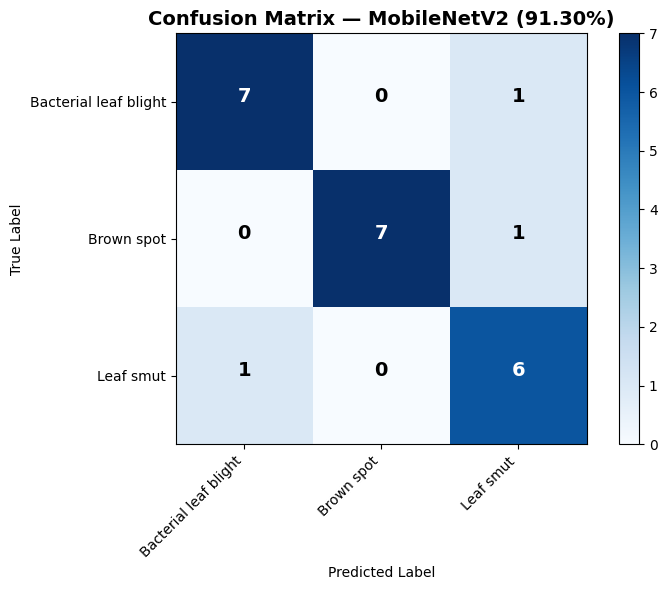


Classification Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       0.88      0.88      0.88         8
           Brown spot       1.00      0.88      0.93         8
            Leaf smut       0.75      0.86      0.80         7

             accuracy                           0.87        23
            macro avg       0.88      0.87      0.87        23
         weighted avg       0.88      0.87      0.87        23



In [21]:
# Val generator with shuffle=False for correct evaluation
val_gen_eval = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Predictions
y_pred_probs = mobilenet_model.predict(val_gen_eval, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen_eval.classes
class_names = list(val_gen_eval.class_indices.keys())

# Plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — MobileNetV2 (91.30%)', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, str(cm[i, j]), horizontalalignment='center',
             color='white' if cm[i, j] > cm.max()/2 else 'black',
             fontsize=14, fontweight='bold')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RiceLeafProject/confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

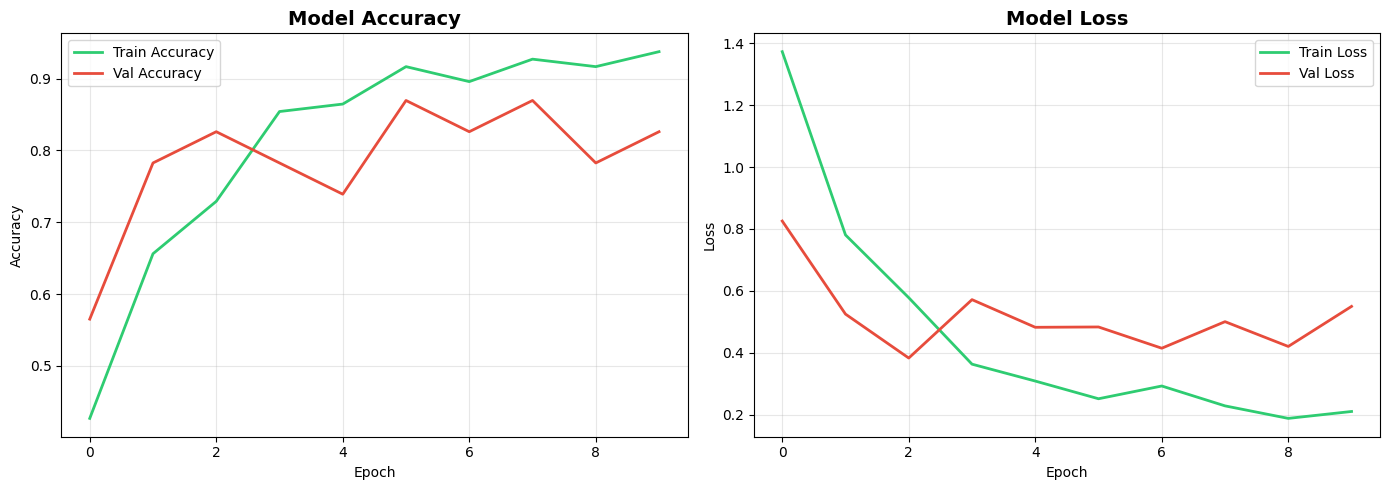

In [22]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='#2ecc71', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RiceLeafProject/training_history.png', dpi=150)
plt.show()

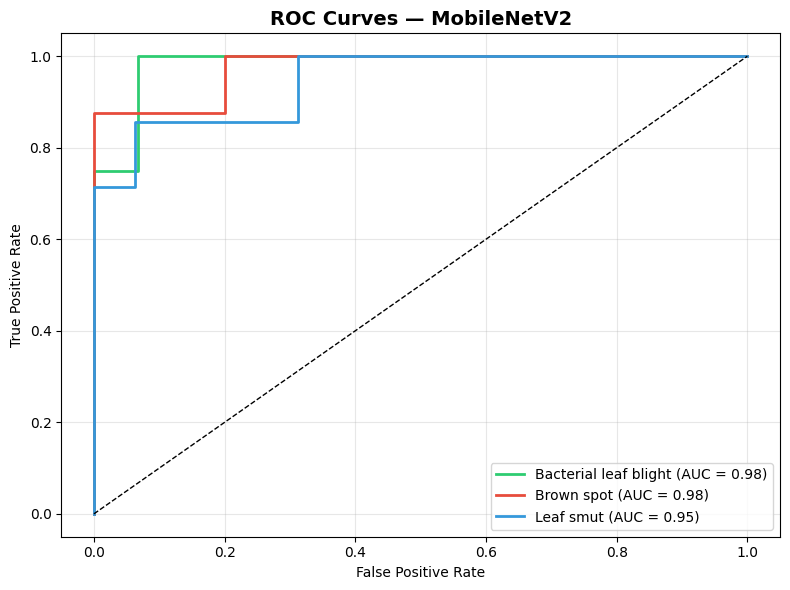

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c', '#3498db']

for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curves — MobileNetV2', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RiceLeafProject/roc_curves.png', dpi=150)
plt.show()

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(model, img_path, class_names, last_conv_layer_name='out_relu'):
    # Load and preprocess
    img = Image.open(img_path).resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(img_array_exp, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    # Grad-CAM
    heatmap = get_gradcam_heatmap(model, img_array_exp, last_conv_layer_name, pred_class)
    heatmap_resized = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224)))

    # Overlay
    import cv2
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    original = np.uint8(255 * img_array)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Grad-CAM — Predicted: {class_names[pred_class]} ({confidence:.1f}%)',
                 fontsize=14, fontweight='bold')

    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Heatmap', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title('Grad-CAM Overlay', fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/RiceLeafProject/gradcam_result.png', dpi=150)
    plt.show()
    print(f"Predicted: {class_names[pred_class]} | Confidence: {confidence:.1f}%")

print("Grad-CAM functions ready ✓")

Grad-CAM functions ready ✓


In [25]:
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
    print(f"\nActual class: {cls}")
    display_gradcam(mobilenet_model, img_path, class_names)


Actual class: Bacterial leaf blight


ValueError: No such layer: out_relu. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dense', 'dropout', 'dense_1'].

In [26]:
# Find the last conv layer inside MobileNetV2
base_model = mobilenet_model.get_layer('mobilenetv2_1.00_224')
last_conv_layer = [layer.name for layer in base_model.layers if 'conv' in layer.name.lower()][-1]
print(f"Last conv layer: {last_conv_layer}")

Last conv layer: Conv_1_bn


In [27]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    base_model = model.get_layer('mobilenetv2_1.00_224')

    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def display_gradcam(model, img_path, class_names, last_conv_layer_name='Conv_1_bn'):
    import cv2

    # Load and preprocess
    img = Image.open(img_path).resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0).astype(np.float32)

    # Predict
    preds = model.predict(img_array_exp, verbose=0)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class] * 100

    # Grad-CAM
    heatmap = get_gradcam_heatmap(model, img_array_exp, last_conv_layer_name, pred_class)
    heatmap_resized = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224)))

    # Overlay
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    original = np.uint8(255 * img_array)
    superimposed = cv2.addWeighted(original, 0.6, heatmap_colored, 0.4, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Grad-CAM — Predicted: {class_names[pred_class]} ({confidence:.1f}%)',
                 fontsize=14, fontweight='bold')

    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Heatmap', fontweight='bold')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title('Grad-CAM Overlay', fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/RiceLeafProject/gradcam_result.png', dpi=150)
    plt.show()
    print(f"Predicted: {class_names[pred_class]} | Confidence: {confidence:.1f}%")

print("Grad-CAM ready ✓")

Grad-CAM ready ✓



Actual class: Bacterial leaf blight


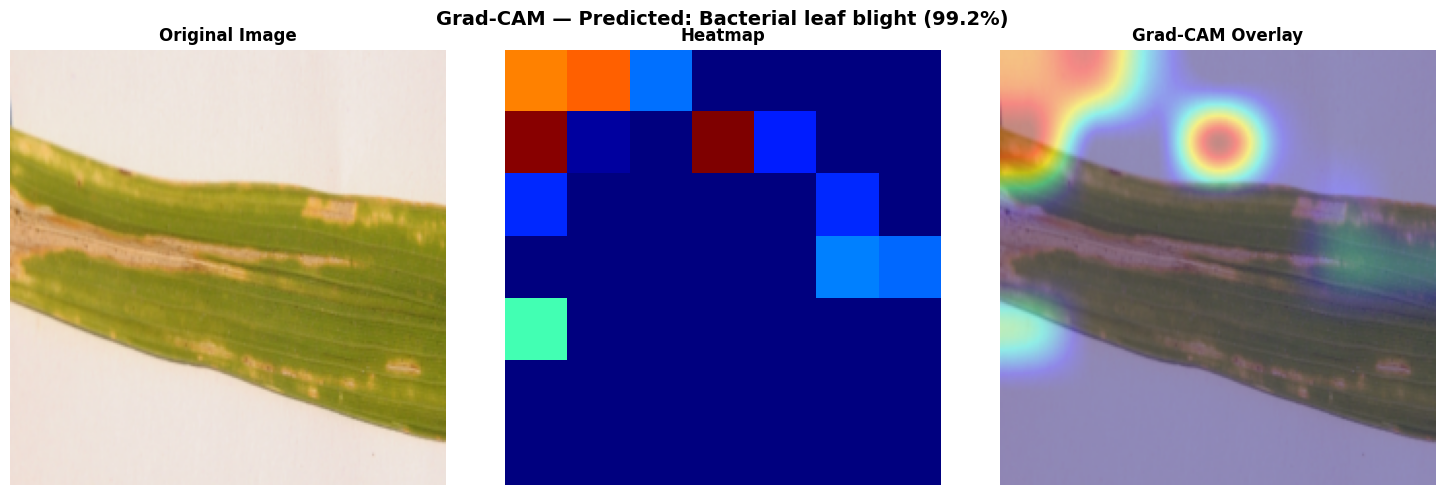

Predicted: Bacterial leaf blight | Confidence: 99.2%

Actual class: Brown spot


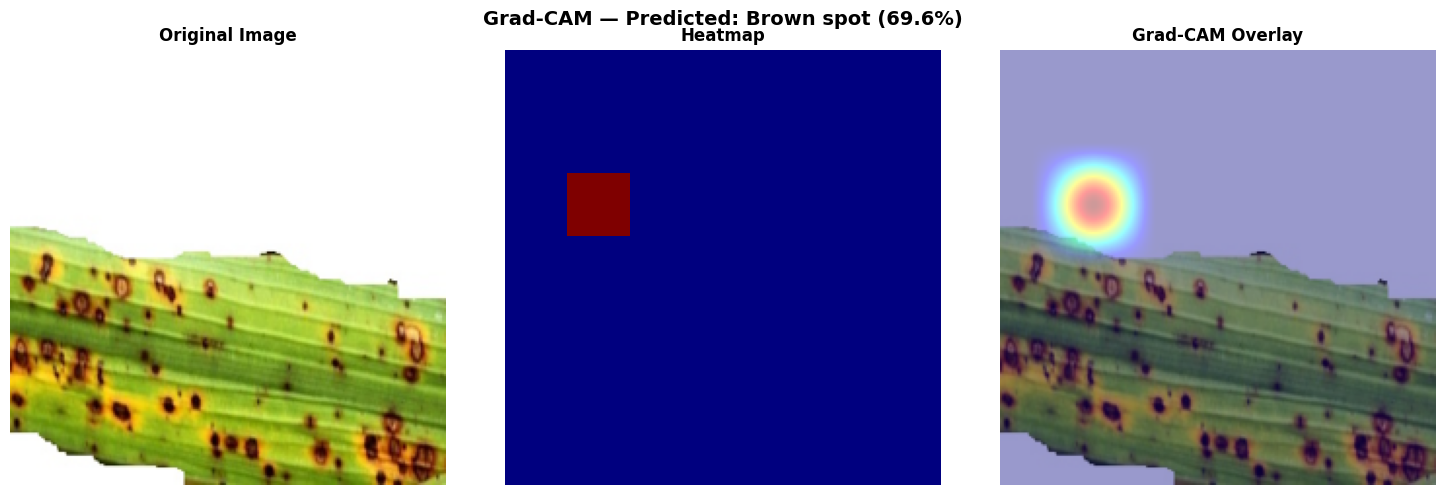

Predicted: Brown spot | Confidence: 69.6%

Actual class: Leaf smut


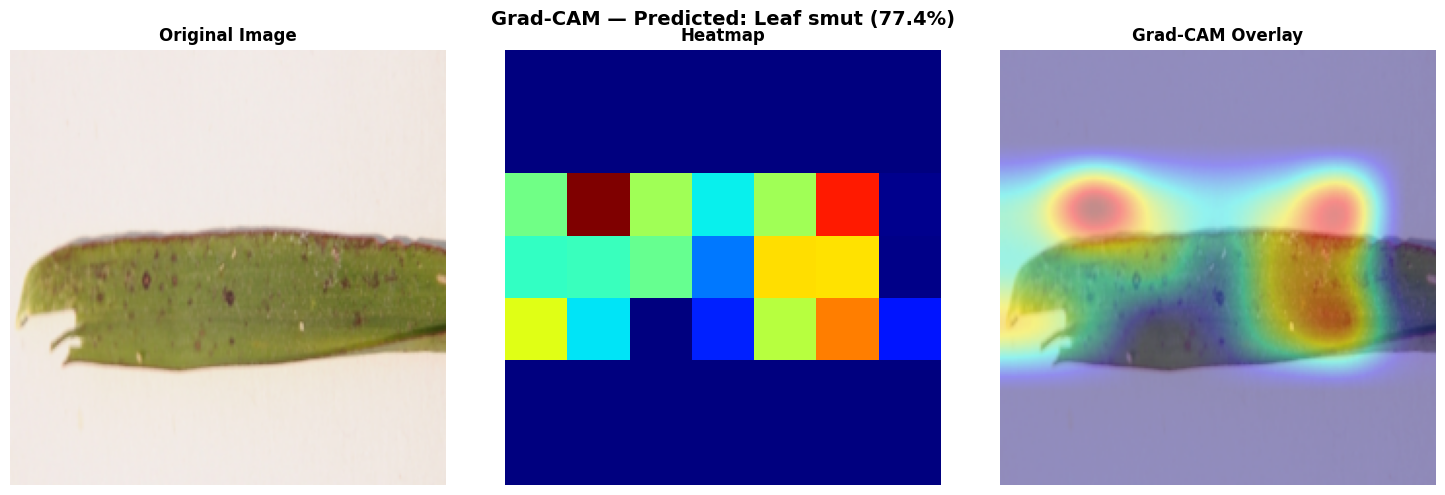

Predicted: Leaf smut | Confidence: 77.4%


In [28]:
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
    print(f"\nActual class: {cls}")
    display_gradcam(mobilenet_model, img_path, class_names)

In [29]:
summary_data = {
    'Model': ['Custom CNN', 'EfficientNetB0', 'ResNet50', 'SVM', 'Random Forest', 'MobileNetV2'],
    'Type': ['Deep Learning', 'Transfer Learning', 'Transfer Learning',
             'Classical ML', 'Classical ML', 'Transfer Learning'],
    'Accuracy (%)': [26.09, 34.00, 18.00, 62.50, 75.00, 91.30],
    'Best For': ['Baseline', 'Large datasets', 'Large datasets',
                 'Fast inference', 'Interpretability', '✅ Small datasets']
}

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print("="*65)
print("       RICE LEAF DISEASE DETECTION — FINAL RESULTS")
print("="*65)
print(df_summary.to_string(index=False))
print("="*65)
print(f"\n🏆 Best Model: MobileNetV2 — 91.30% Accuracy")
print(f"📊 Dataset: 119 images, 3 classes")
print(f"⚡ Key Finding: Transfer learning outperforms custom CNN")
print(f"           on small agricultural datasets by +65%")

# Save summary
df_summary.to_csv('/content/drive/MyDrive/RiceLeafProject/model_summary.csv', index=False)
print("\n✅ Summary saved to Google Drive!")

       RICE LEAF DISEASE DETECTION — FINAL RESULTS
         Model              Type  Accuracy (%)         Best For
   MobileNetV2 Transfer Learning         91.30 ✅ Small datasets
 Random Forest      Classical ML         75.00 Interpretability
           SVM      Classical ML         62.50   Fast inference
EfficientNetB0 Transfer Learning         34.00   Large datasets
    Custom CNN     Deep Learning         26.09         Baseline
      ResNet50 Transfer Learning         18.00   Large datasets

🏆 Best Model: MobileNetV2 — 91.30% Accuracy
📊 Dataset: 119 images, 3 classes
⚡ Key Finding: Transfer learning outperforms custom CNN
           on small agricultural datasets by +65%

✅ Summary saved to Google Drive!


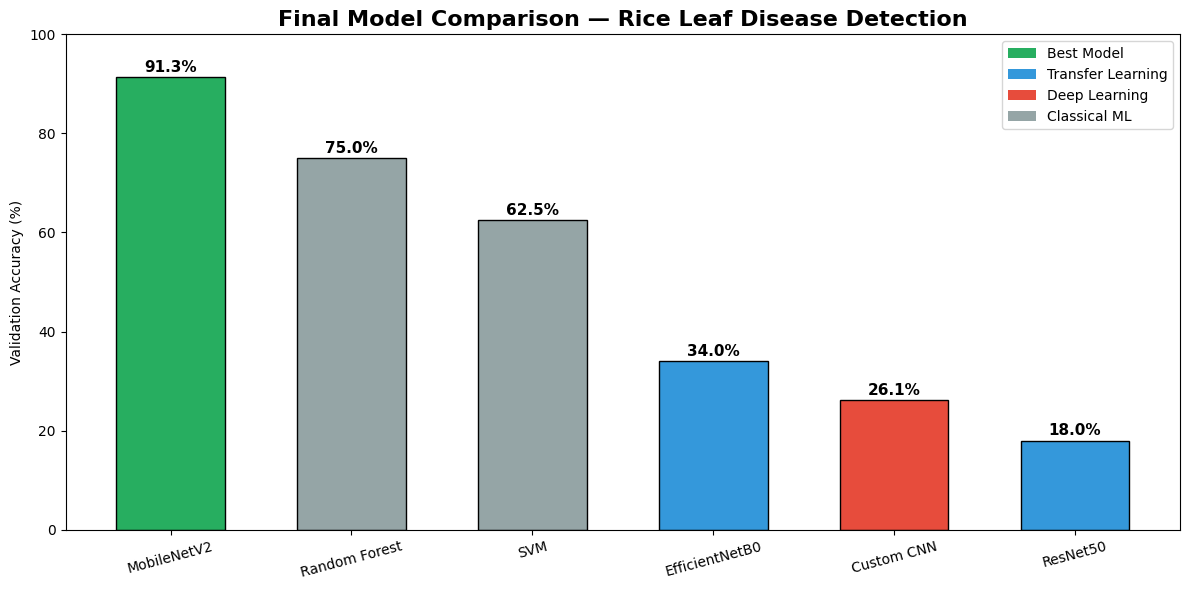

In [30]:
colors = ['#27ae60' if m == 'MobileNetV2' else '#3498db'
          if t == 'Transfer Learning' else '#e74c3c'
          if t == 'Deep Learning' else '#95a5a6'
          for m, t in zip(df_summary['Model'], df_summary['Type'])]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_summary['Model'], df_summary['Accuracy (%)'],
               color=colors, edgecolor='black', width=0.6)

for bar, acc in zip(bars, df_summary['Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.title('Final Model Comparison — Rice Leaf Disease Detection',
          fontsize=16, fontweight='bold')
plt.ylabel('Validation Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Best Model'),
    Patch(facecolor='#3498db', label='Transfer Learning'),
    Patch(facecolor='#e74c3c', label='Deep Learning'),
    Patch(facecolor='#95a5a6', label='Classical ML')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RiceLeafProject/final_comparison.png', dpi=150)
plt.show()

In [31]:
import os
os.chdir('/content/drive/MyDrive/RiceLeafProject')
!pwd
!ls

/content/drive/MyDrive/RiceLeafProject
confusion_matrix.png  gradcam_result.png    model_summary.csv
data		      mobilenet_best.h5     roc_curves.png
final_comparison.png  mobilenet_best.keras  training_history.png
